## Classify the news article to a topic

In [1]:
from keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
word_index = reuters.get_word_index()
reversed_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_newswire = " ".join(
    [reversed_word_index.get(i - 3, "?") for i in train_data[0]]
)

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

In [4]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

# Vectorized training labels
y_train = one_hot_encode(train_labels)
# Vectorized test labels
y_test = one_hot_encode(test_labels)

### Define the model architecture

In [7]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

In [8]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

In [11]:
# Vectorized training data
x_train = multi_hot_encode(train_data, num_classes=10000)
# Vectorized test data
x_test = multi_hot_encode(test_data, num_classes=10000)

In [12]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### Split data into training and validation

In [13]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.3520 - loss: 3.2194 - top_3_accuracy: 0.5552 - val_accuracy: 0.4910 - val_loss: 2.4392 - val_top_3_accuracy: 0.6880
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.5814 - loss: 1.9272 - top_3_accuracy: 0.7290 - val_accuracy: 0.6350 - val_loss: 1.5950 - val_top_3_accuracy: 0.7690
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.7136 - loss: 1.3411 - top_3_accuracy: 0.8066 - val_accuracy: 0.7120 - val_loss: 1.2830 - val_top_3_accuracy: 0.8160
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.7702 - loss: 1.0439 - top_3_accuracy: 0.8538 - val_accuracy: 0.7540 - val_loss: 1.1247 - val_top_3_accuracy: 0.8440
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.8190 - loss: 0.8282 - top_3_accuracy: 0.9029 - val_accuracy: 0.7690 - val_loss: 1.0296 - val_top_3_accuracy: 0.8800
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8574 - loss: 0.6570 - to

### Analyze the result

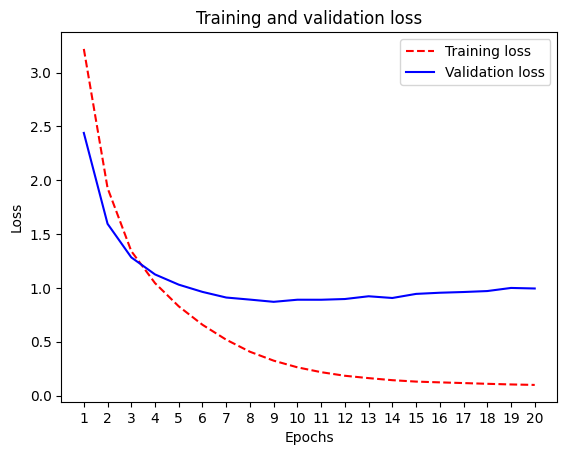

In [14]:
import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

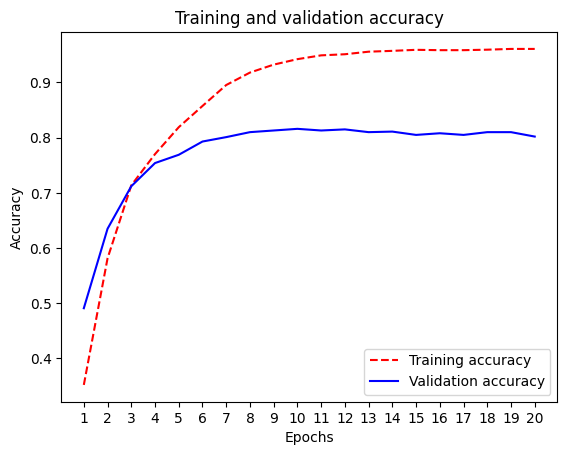

In [15]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Rerun the training data (include validation) for optimal epochs

In [16]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.3962 - loss: 3.0524
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6290 - loss: 1.7400
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7306 - loss: 1.2356
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7966 - loss: 0.9527
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8451 - loss: 0.7401
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8827 - loss: 0.5704
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9108 - loss: 0.4355
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9265 - loss: 0.3393
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9409 - loss: 0.2676
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8005 - loss: 0.9176


In [17]:
results

[0.9175726175308228, 0.8005343079566956]